# 1. Problem Overview & Dataset Structure

Assessing damage from photographs is a critical step in verifying claims in the context of motor insurance, which can help to prioritise workload for assessors and aid the detection of potentially fraudulent submissions. To do this manually would mean inspecting every image in a time‑consuming and subjective process that can never compete with an automated computer‑vision model especially in terms of faster and more consistent decision‑making.

In this project, a **Convolutional Neural Network (CNN)** was developed to perform a **multi‑class image classification** task which involves predicting the **type of vehicle damage** present in each image, using six damage categories:
- **1 → crack**
- **2 → scratch**
- **3 → tire flat**
- **4 → dent**
- **5 → glass shatter**
- **6 → lamp broken**

## Dataset structure

The dataset is organised into separate training and test folders, each containing image files and a CSV file:

- `train/`
  - `images/` – folder containing all training images (e.g. `img_1.jpg`, `img_2.jpg`, ...)
  - `train.csv` – metadata for the training set with three columns:
    - `image_id` – unique identifier for each record
    - `filename` – image file name (e.g. `img_1.jpg`)
    - `label` – integer code indicating the damage type (1–6)
- `test/`
  - `images/` – folder containing all test images
  - `test.csv` – metadata for the test set with at least:
    - `image_id` – unique identifier for each record
    - `filename` – image file name for each test image (no label)

The goal is to trained and validated the model on the labelled training images, and then use it to generate predictions for the unlabelled test images.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Working directory:", Path.cwd().name)

# Define paths to CSV files
TRAIN_CSV_PATH = Path('train') / 'train.csv'
TEST_CSV_PATH = Path('test') / 'test.csv'

train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

print("\nTrain dataframe head:")
display(train_df.head())

print("\nUnique class labels in training data:", sorted(train_df['label'].unique()))

print("\nTest dataframe head:")
display(test_df.head())

Working directory: archive

Train dataframe head:


C:\Users\CU3E\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


,image_id,filename,label
0,1,1.jpg,2
1,2,2.jpg,4
2,3,3.jpg,2
3,4,4.jpg,3
4,5,5.jpg,5



Unique class labels in training data: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Test dataframe head:


,image_id,filename
0,7201,7201.jpg
1,7202,7202.jpg
2,7203,7203.jpg
3,7204,7204.jpg
4,7205,7205.jpg


# 2. Data Loading & Exploration

This section explores the labelled training data to understand the class balance and to verify whether the image references in the CSV files align with the image folders.

Label counts:
 label
1     171
2    2349
3     534
4    2079
5    1185
6     882
Name: count, dtype: int64

Class distribution table:


,label,damage_type,count,percentage
0,1,crack,171,2.375000
1,2,scratch,2349,32.625000
2,3,tire flat,534,7.416667
3,4,dent,2079,28.875000
4,5,glass shatter,1185,16.458333
5,6,lamp broken,882,12.250000


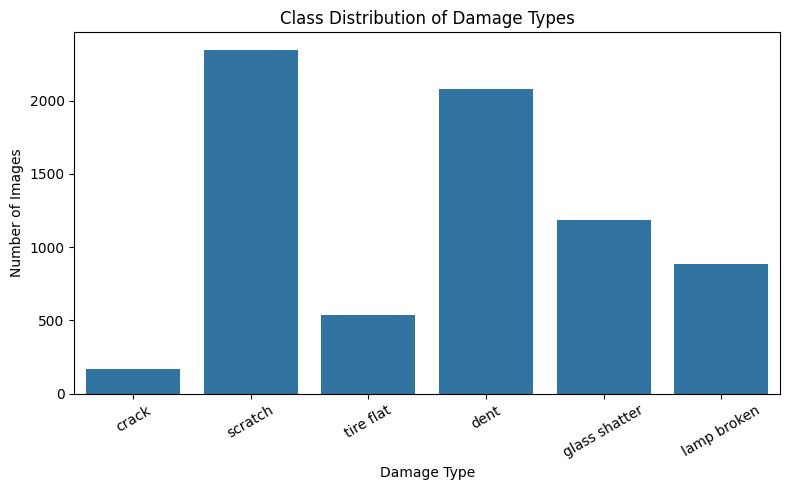

In [2]:
# Inspect basic class distribution
label_counts = train_df['label'].value_counts().sort_index()
print("Label counts:\n", label_counts)

# Map integer labels to human‑readable damage types
label_to_name = {
    1: 'crack',
    2: 'scratch',
    3: 'tire flat',
    4: 'dent',
    5: 'glass shatter',
    6: 'lamp broken'
}

train_df['damage_type'] = train_df['label'].map(label_to_name)

class_distribution = (
    train_df.groupby(['label', 'damage_type'])['image_id']
    .count()
    .reset_index()
    .rename(columns={'image_id': 'count'})
)
class_distribution['percentage'] = 100 * class_distribution['count'] / len(train_df)

print("\nClass distribution table:")
display(class_distribution)

# Plot class distribution by damage type
plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_distribution.sort_values('label'),
    x='damage_type',
    y='count'
)
plt.title('Class Distribution of Damage Types')
plt.xlabel('Damage Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

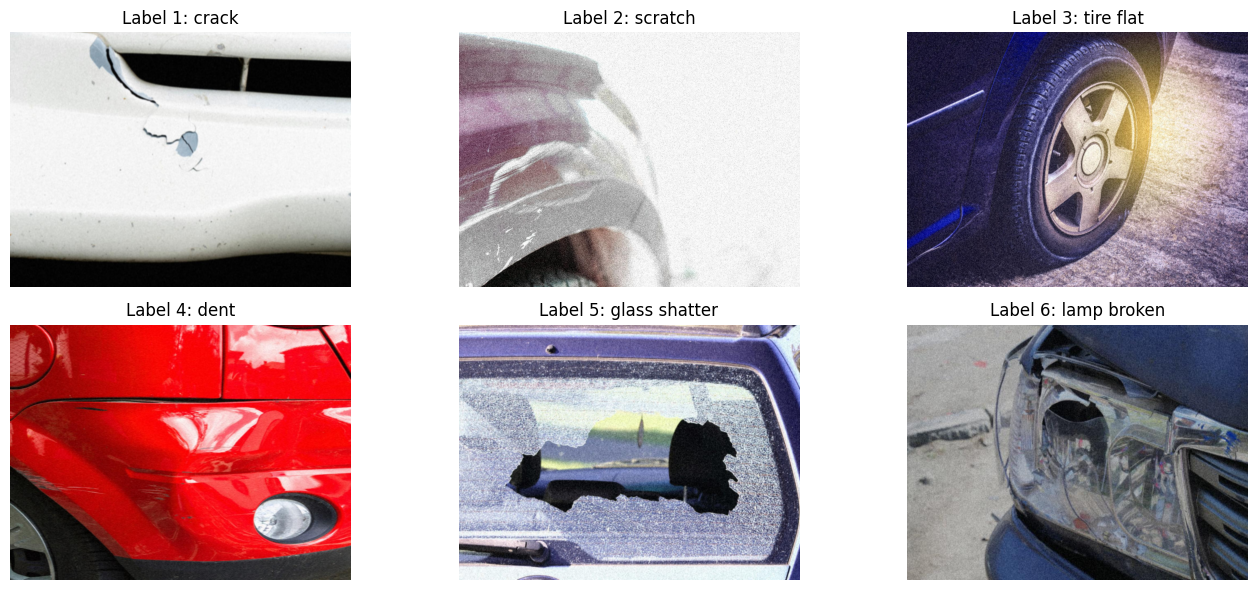

In [3]:
# Visual sanity checks: show one example image from each class
from PIL import Image

TRAIN_IMG_DIR = Path('train') / 'images'
TEST_IMG_DIR = Path('test') / 'images'

examples = []
for label in sorted(label_to_name.keys()):
    example_row = train_df[train_df['label'] == label].iloc[0]
    examples.append(example_row)

n_classes = len(examples)
plt.figure(figsize=(14, 6))
for idx, row in enumerate(examples, 1):
    img_path = TRAIN_IMG_DIR / row['filename']
    try:
        img = Image.open(img_path).convert('RGB')
        plt.subplot(2, 3, idx)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Label {row['label']}: {row['damage_type']}")
    except FileNotFoundError:
        print(f"Image not found: {img_path}")
plt.tight_layout()
plt.show()

The table and bar chart above show the frequency of each type of damage in the training set. The imbalance will be addressed later using class weights and targeted data augmentation.

# 3. Data Preprocessing & Generators

All the images were resized to a common spatial resolution that is suitable for CNN training. Furthermore, the labelled data is split into stratified training and validation sets to preserve the original class proportions. Keras `ImageDataGenerator` objects are then used to stream images from disk with on‑the‑fly data augmentation for the training split.

In [4]:
# Configuration constants
IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
BATCH_SIZE = 32
NUM_CLASSES = len(label_to_name)

# Add a readable damage_type_name column
train_df['damage_type_name'] = train_df['label'].map(label_to_name)

# Stratified train/validation split
train_df_split, val_df_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df['label']
)

print(f"Training samples: {len(train_df_split)}")
print(f"Validation samples: {len(val_df_split)}")

Training samples: 5760
Validation samples: 1440


In [5]:
# Create ImageDataGenerators for training and validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Flow images from dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_split,
    directory=str(TRAIN_IMG_DIR),
    x_col='filename',
    y_col='damage_type_name',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_STATE
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df_split,
    directory=str(TRAIN_IMG_DIR),
    x_col='filename',
    y_col='damage_type_name',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass indices (generator mapping):")
print(train_generator.class_indices)

print("\nSamples per class in training split:")
display(train_df_split['damage_type_name'].value_counts())

# Optional: test generator for later predictions
test_datagen = ImageDataGenerator(rescale=1.0/255.0)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=str(TEST_IMG_DIR),
    x_col='filename',
    y_col=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=False
)

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.

Class indices (generator mapping):
{'crack': 0, 'dent': 1, 'glass shatter': 2, 'lamp broken': 3, 'scratch': 4, 'tire flat': 5}

Samples per class in training split:


damage_type_name
scratch          1879
dent             1663
glass shatter     948
lamp broken       706
tire flat         427
crack             137
Name: count, dtype: int64

Found 4800 validated image filenames.


# 4. Q(a) – Baseline CNN Architecture and Justification

This section defined and trained an initial baseline CNN model. The architecture was made deliberately simple but expressive enough for six‑class damage classification. This follows a conventional structure of stacked convolutional blocks, which was followed by fully connected layers and a softmax output layer.

In [6]:
def build_baseline_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), num_classes=NUM_CLASSES):
    """Build a baseline CNN for multi‑class damage classification."""
    inputs = layers.Input(shape=input_shape)

    # Convolutional block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convolutional block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Convolutional block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='baseline_cnn')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_cnn()
print("=== 4.1 Baseline CNN Summary ===")
baseline_model.summary()

=== 4.1 Baseline CNN Summary ===


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [7]:
# Compute class weights to address potential imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights = {int(label): weight for label, weight in zip(np.unique(train_df['label']), class_weights)}
print("\nComputed class weights:")
print(class_weights)


Computed class weights:
{1: np.float64(7.017543859649122), 2: np.float64(0.5108556832694764), 3: np.float64(2.247191011235955), 4: np.float64(0.5772005772005772), 5: np.float64(1.0126582278481013), 6: np.float64(1.3605442176870748)}


In [8]:
# Train the baseline model
EPOCHS_BASELINE = 2   # fine for baseline / demonstration

baseline_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history_baseline = baseline_model.fit(
    train_generator,
    epochs=EPOCHS_BASELINE,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=baseline_callbacks,   # added this
    verbose=1
)


Epoch 1/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.3547 - loss: 3.8879 - val_accuracy: 0.2889 - val_loss: 64.3909
Epoch 2/2
180/180 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.3609 - loss: 2.0979 - val_accuracy: 0.2889 - val_loss: 9.2022


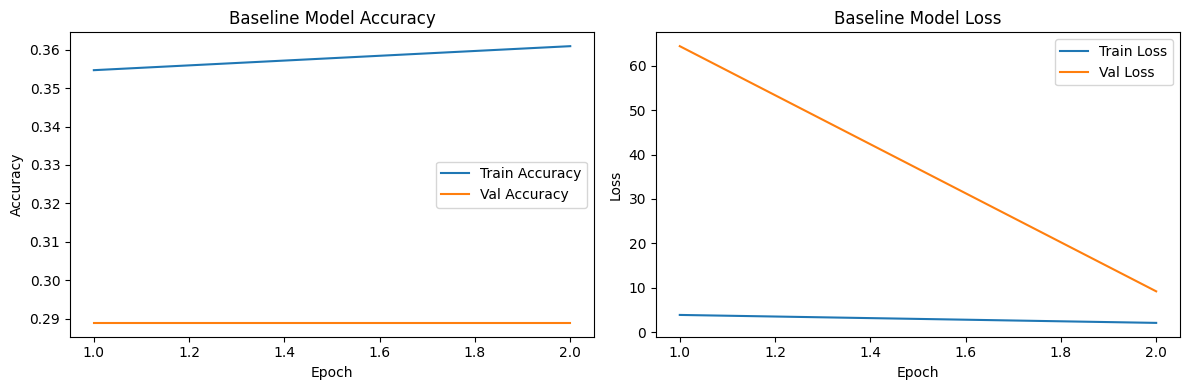

Baseline validation accuracy: 0.2889
Baseline validation loss: 9.2022


In [9]:
# Plot baseline training history
def plot_training_history(history, title_prefix=""):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_training_history(history_baseline, title_prefix='Baseline Model ')

baseline_val_loss, baseline_val_acc = baseline_model.evaluate(val_generator, verbose=0)
print(f"Baseline validation accuracy: {baseline_val_acc:.4f}")
print(f"Baseline validation loss: {baseline_val_loss:.4f}")

The baseline CNN used three convolutional blocks with 3×3 kernels, batch normalisation and max‑pooling to extract increasingly abstract spatial features. These were then followed by a dense layer with ReLU activation and a softmax output layer that produced a probability distribution over the six damage classes. The input resolution of 224×224×3 provides balance in terms of spatial detail and computational cost, and a batch size of 32 served a good compromise between stable gradient estimates and coputational memory usage.

# 5. Q(b) – Regularisation Experiments

To improve generalisation and reduce overfitting chances, the baseline CNN was extended with **regularisation techniques**:

- **Dropout** layers after the convolutional and dense blocks in order to randomly deactivate neurons during training.
- **L2 weight decay** applied to some selected convolutional and dense layers in order to discourage overly large weights.
- **Data augmentation** (already implemented in the training generator) to expose the model to plausible visual variations of each type of damage.

The impact of these techniques was assessed by comparing the training and validation performance against the baseline results from Section 4.

In [10]:
def build_regularised_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=NUM_CLASSES,
    l2_factor=1e-4,
    dropout_rate=0.5,
    base_filters=32,
    learning_rate=1e-3,   # added new
):
    """Build a CNN with dropout and L2 regularisation."""
    reg = regularizers.l2(l2_factor)
    inputs = layers.Input(shape=input_shape)

    # Convolutional block 1
    x = layers.Conv2D(base_filters, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate / 2)(x)

    # Convolutional block 2
    x = layers.Conv2D(base_filters * 2, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate / 2)(x)

    # Convolutional block 3
    x = layers.Conv2D(base_filters * 4, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)

    # Flatten and dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='regularised_cnn')
    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),  # use param
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

regularised_model = build_regularised_cnn()
regularised_model.summary()


Model: "regularised_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,787,078 (98.37 MB)

 Trainable params: 25,786,118 (98.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
# Train the regularised model
EPOCHS_REG = 20

regularised_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

history_regularised = regularised_model.fit(
    train_generator,
    epochs=EPOCHS_REG,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=regularised_callbacks,
    verbose=1
)

Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 389s 2s/step - accuracy: 0.3064 - loss: 4.3006 - val_accuracy: 0.2889 - val_loss: 80.5951
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.3290 - loss: 2.8994 - val_accuracy: 0.2889 - val_loss: 5.3667
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.3502 - loss: 2.7017 - val_accuracy: 0.3118 - val_loss: 4.5874
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.3750 - loss: 2.5445 - val_accuracy: 0.3313 - val_loss: 24.0557
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.3854 - loss: 2.4312 - val_accuracy: 0.3736 - val_loss: 34.9523
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.3819 - loss: 2.5244 - val_accuracy: 0.2910 - val_loss: 5.4979
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.3752 - loss: 2.6522 - val_accuracy: 0.3528 - val_loss: 2.6620
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.3920 - loss: 2.5923 - val_a

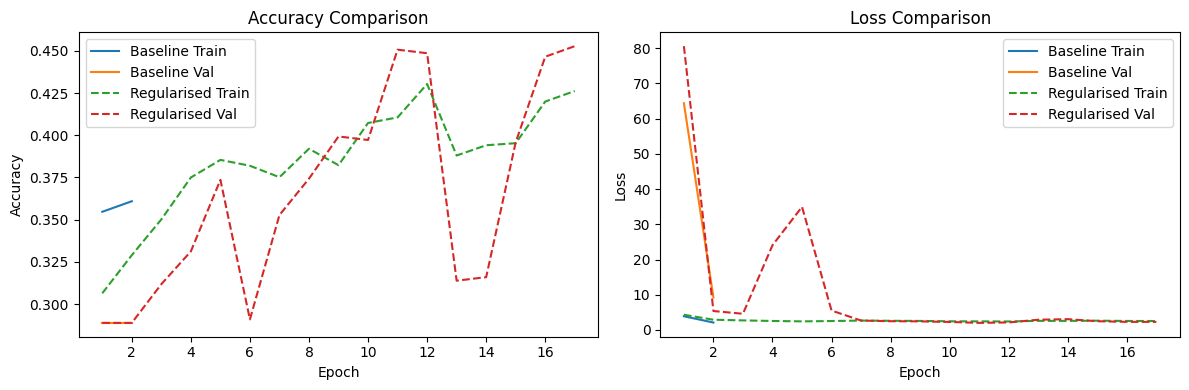

Regularised validation accuracy: 0.4507
Regularised validation loss: 1.9999

Validation performance comparison:


,model,val_accuracy,val_loss
0,baseline,0.288889,9.202246
1,regularised,0.450694,1.999926


In [12]:
# Compare baseline and regularised training curves
def plot_two_histories(hist1, hist2, labels=('Baseline', 'Regularised')):
    acc1 = hist1.history.get('accuracy', [])
    val_acc1 = hist1.history.get('val_accuracy', [])
    acc2 = hist2.history.get('accuracy', [])
    val_acc2 = hist2.history.get('val_accuracy', [])

    epochs1 = range(1, len(acc1) + 1)
    epochs2 = range(1, len(acc2) + 1)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs1, acc1, label=f'{labels[0]} Train')
    plt.plot(epochs1, val_acc1, label=f'{labels[0]} Val')
    plt.plot(epochs2, acc2, '--', label=f'{labels[1]} Train')
    plt.plot(epochs2, val_acc2, '--', label=f'{labels[1]} Val')
    plt.title('Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    loss1 = hist1.history.get('loss', [])
    val_loss1 = hist1.history.get('val_loss', [])
    loss2 = hist2.history.get('loss', [])
    val_loss2 = hist2.history.get('val_loss', [])

    plt.subplot(1, 2, 2)
    plt.plot(epochs1, loss1, label=f'{labels[0]} Train')
    plt.plot(epochs1, val_loss1, label=f'{labels[0]} Val')
    plt.plot(epochs2, loss2, '--', label=f'{labels[1]} Train')
    plt.plot(epochs2, val_loss2, '--', label=f'{labels[1]} Val')
    plt.title('Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_two_histories(history_baseline, history_regularised)

reg_val_loss, reg_val_acc = regularised_model.evaluate(val_generator, verbose=0)
print(f"Regularised validation accuracy: {reg_val_acc:.4f}")
print(f"Regularised validation loss: {reg_val_loss:.4f}")

comparison_df = pd.DataFrame({
    'model': ['baseline', 'regularised'],
    'val_accuracy': [baseline_val_acc, reg_val_acc],
    'val_loss': [baseline_val_loss, reg_val_loss]
})
print("\nValidation performance comparison:")
display(comparison_df)

The results above allow a direct comparison between the baseline and regularised CNN models. Dropout and L2 weight decay can be expected to typically reduce the gap between training and validation accuracy and demonstrate improved generalisation, even if peak training accuracy is slightly lower. Data augmentation goes further to encourage robustness by exposing the model to realistic variations in terms of viewing angle, position and scale.

# 6. Q(c) – Hyperparameter Tuning & Performance Analysis

This section performed a lightweight hyperparameter tuning on the regularised CNN. The key hyperparameters considered include:
- **Learning rate** of the Adam optimiser
- **Batch size**
- **Number of filters** in the first convolutional layer (which scales the whole network)

A small grid of configurations was evaluated and the validation performance was then used to select the final model.

In [13]:
# Hyperparameter configurations (desktop: 32 GB RAM)
hyperparameter_configs = [
    {'name': 'config_1', 'learning_rate': 1e-3,  'batch_size': 32, 'base_filters': 32},
    {'name': 'config_2', 'learning_rate': 5e-4, 'batch_size': 32, 'base_filters': 32},
    {'name': 'config_3', 'learning_rate': 1e-3,  'batch_size': 32, 'base_filters': 64},
    {'name': 'config_4', 'learning_rate': 5e-4, 'batch_size': 32, 'base_filters': 64},
]

tuning_results = []

for config in hyperparameter_configs:
    print("\n=== Training", config['name'], "===")
    batch_size = config['batch_size']

    # Rebuild generators for this batch size
    train_generator_tune = train_datagen.flow_from_dataframe(
        dataframe=train_df_split,
        directory=str(TRAIN_IMG_DIR),
        x_col='filename',
        y_col='damage_type_name',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=True,
        seed=RANDOM_STATE
    )

    val_generator_tune = val_datagen.flow_from_dataframe(
        dataframe=val_df_split,
        directory=str(TRAIN_IMG_DIR),
        x_col='filename',
        y_col='damage_type_name',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )

    # Build model with learning rate from config
    model_tune = build_regularised_cnn(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        num_classes=NUM_CLASSES,
        l2_factor=1e-4,
        dropout_rate=0.5,
        base_filters=config['base_filters'],
        learning_rate=float(config['learning_rate'])   # added this later
    )

    callbacks_tune = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]

    history_tune = model_tune.fit(
        train_generator_tune,
        epochs=12,                      # real tuning now
        validation_data=val_generator_tune,
        class_weight=class_weights,
        callbacks=callbacks_tune,       # used callbacks
        verbose=1
    )

    val_loss, val_acc = model_tune.evaluate(val_generator_tune, verbose=0)
    tuning_results.append({
        'name': config['name'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'base_filters': config['base_filters'],
        'val_accuracy': val_acc,
        'val_loss': val_loss
    })

tuning_results_df = pd.DataFrame(tuning_results)
print("\nHyperparameter tuning results:")
display(tuning_results_df.sort_values('val_accuracy', ascending=False))



=== Training config_1 ===
Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.
Epoch 1/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.2804 - loss: 4.7773 - val_accuracy: 0.2889 - val_loss: 14.9225
Epoch 2/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.3363 - loss: 2.9977 - val_accuracy: 0.2889 - val_loss: 6.0238
Epoch 3/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.3559 - loss: 2.6903 - val_accuracy: 0.2917 - val_loss: 3.7404
Epoch 4/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - accuracy: 0.3644 - loss: 2.6326 - val_accuracy: 0.3910 - val_loss: 2.3178
Epoch 5/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.3686 - loss: 2.5813 - val_accuracy: 0.3875 - val_loss: 2.2646
Epoch 6/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.3859 - loss: 2.4853 - val_accuracy: 0.4111 - val_loss: 2.2509
Epoch 7/12
180/180 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.3950 - lo

,name,learning_rate,batch_size,base_filters,val_accuracy,val_loss
2,config_3,0.0010,32,64,0.479861,2.071896
3,config_4,0.0005,32,64,0.479167,1.915015
1,config_2,0.0005,32,32,0.470139,1.890763
0,config_1,0.0010,32,32,0.440278,2.025589


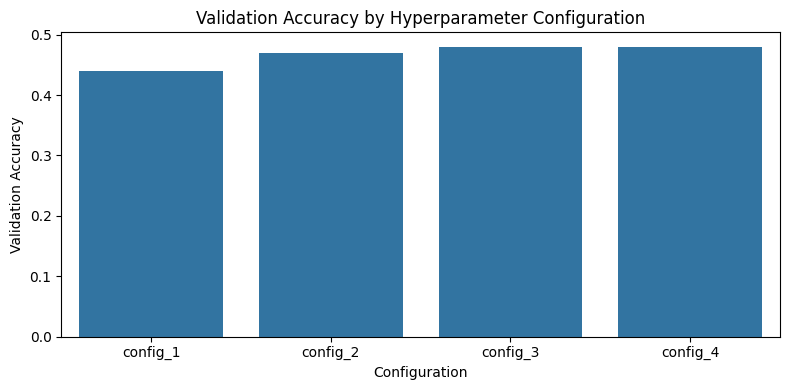

Best configuration:
{'name': 'config_3', 'learning_rate': 0.001, 'batch_size': 32, 'base_filters': 64, 'val_accuracy': 0.4798611104488373, 'val_loss': 2.0718958377838135}


In [14]:
# Visualise validation accuracy by configuration
plt.figure(figsize=(8, 4))
sns.barplot(data=tuning_results_df, x='name', y='val_accuracy')
plt.title('Validation Accuracy by Hyperparameter Configuration')
plt.xlabel('Configuration')
plt.ylabel('Validation Accuracy')
plt.tight_layout()
plt.show()

# Identify best configuration
best_config_row = tuning_results_df.sort_values('val_accuracy', ascending=False).iloc[0]
best_config = best_config_row.to_dict()
print("Best configuration:")
print(best_config)

In [15]:
# Train final model using the best hyperparameter configuration
FINAL_BATCH_SIZE = int(best_config['batch_size'])
FINAL_LR = float(best_config['learning_rate'])
FINAL_BASE_FILTERS = int(best_config['base_filters'])

final_train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_split,
    directory=str(TRAIN_IMG_DIR),
    x_col='filename',
    y_col='damage_type_name',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=FINAL_BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=RANDOM_STATE
)

final_val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df_split,
    directory=str(TRAIN_IMG_DIR),
    x_col='filename',
    y_col='damage_type_name',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=FINAL_BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

final_model = build_regularised_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
    num_classes=NUM_CLASSES,
    l2_factor=1e-4,
    dropout_rate=0.5,
    base_filters=FINAL_BASE_FILTERS,
    learning_rate=FINAL_LR          # used tuned LR
)

final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
]

history_final = final_model.fit(
    final_train_generator,
    epochs=25,                       # desktop
    validation_data=final_val_generator,
    class_weight=class_weights,
    callbacks=final_callbacks,       # actually used callbacks
    verbose=1
)

final_val_loss, final_val_acc = final_model.evaluate(final_val_generator, verbose=0)
print(f"Final model validation accuracy: {final_val_acc:.4f}")
print(f"Final model validation loss: {final_val_loss:.4f}")

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.
Epoch 1/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 983s 5s/step - accuracy: 0.2799 - loss: 4.9752 - val_accuracy: 0.2889 - val_loss: 8.1336
Epoch 2/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 963s 5s/step - accuracy: 0.3104 - loss: 3.4094 - val_accuracy: 0.3000 - val_loss: 3.0207
Epoch 3/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 981s 5s/step - accuracy: 0.3290 - loss: 3.0023 - val_accuracy: 0.2910 - val_loss: 2.9891
Epoch 4/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 977s 5s/step - accuracy: 0.3561 - loss: 2.8179 - val_accuracy: 0.3472 - val_loss: 2.4054
Epoch 5/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 972s 5s/step - accuracy: 0.3731 - loss: 2.6878 - val_accuracy: 0.3972 - val_loss: 2.2592
Epoch 6/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 977s 5s/step - accuracy: 0.3988 - loss: 2.6138 - val_accuracy: 0.3389 - val_loss: 2.5803
Epoch 7/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 1008s 6s/step - accuracy: 0.3984 - loss: 2.5815 - val_accuracy: 

The tuning results help to identify the combination of learning rate, batch size and the base number of filters that achieved the highest validation accuracy. This configuration is then used to train the final regularised CNN model, which subsequently forms the basis for subsequent overfitting analysis and test‑set prediction.

# 7. Q(d) – Overfitting Analysis

This section examined the training dynamics of the final CNN model to check whether any overfitting occurs. Typically, overfitting will be evident if the training accuracy continuing to improve while the validation accuracy plateaus or deteriorates, and also by a growing gap between training and validation loss.

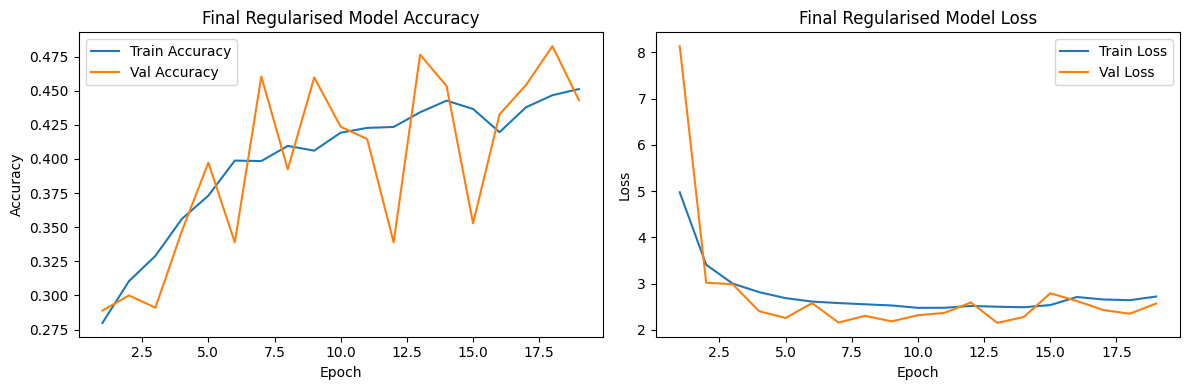

Final training accuracy (last epoch): 0.4512
Final training loss (last epoch): 2.7233
Final validation accuracy (best): 0.4764
Final validation loss (best): 2.1531


In [16]:
# Plot training and validation curves for the final model
plot_training_history(history_final, title_prefix='Final Regularised Model ')

final_train_acc = history_final.history['accuracy'][-1]
final_train_loss = history_final.history['loss'][-1]

print(f"Final training accuracy (last epoch): {final_train_acc:.4f}")
print(f"Final training loss (last epoch): {final_train_loss:.4f}")
print(f"Final validation accuracy (best): {final_val_acc:.4f}")
print(f"Final validation loss (best): {final_val_loss:.4f}")

It is possible to identify whether the model began to memorise the training data instead of learning general patterns by comparing the training and validation curves. In the situation where the training accuracy is substantially higher than the validation accuracy and validation loss stops improving or increases after a certain epoch, it will serve as a clear evidence of overfitting. The early stoppage and the regularisation strategies that were introduced in Section 5 were designed to mitigate this behaviour.

# 8. Final Model Evaluation & Test Predictions

The final step was to evaluate the selected CNN more thoroughly on the validation data and then generate damage type predictions for the separate test set of images. The outputs were then saved to disk so that they can be used for future purposes.

Found 1440 validated image filenames belonging to 6 classes.
45/45 ━━━━━━━━━━━━━━━━━━━━ 39s 861ms/step

Classification report (validation set):
               precision    recall  f1-score   support

        crack       0.00      0.00      0.00        34
         dent       0.38      0.94      0.54       416
glass shatter       0.75      0.75      0.75       237
  lamp broken       0.56      0.30      0.39       176
      scratch       1.00      0.01      0.01       470
    tire flat       0.92      0.57      0.71       107

     accuracy                           0.48      1440
    macro avg       0.60      0.43      0.40      1440
 weighted avg       0.70      0.48      0.38      1440



C:\Users\CU3E\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\CU3E\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\CU3E\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

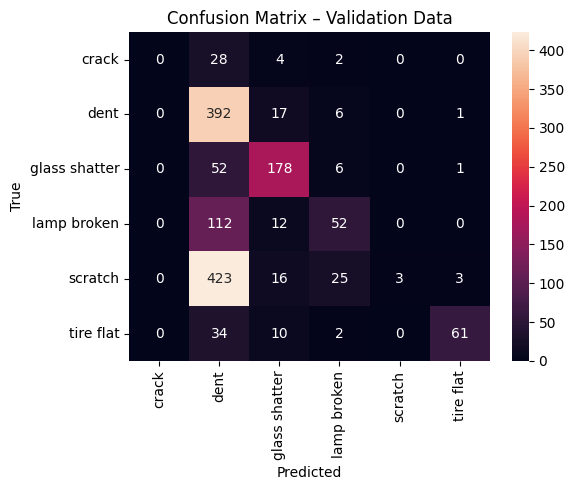

In [17]:
# Detailed evaluation on validation data
val_generator_eval = val_datagen.flow_from_dataframe(
    dataframe=val_df_split,
    directory=str(TRAIN_IMG_DIR),
    x_col='filename',
    y_col='damage_type_name',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=FINAL_BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

val_steps = int(np.ceil(len(val_df_split) / FINAL_BATCH_SIZE))
val_preds_prob = final_model.predict(val_generator_eval, steps=val_steps, verbose=1)
val_pred_labels_idx = np.argmax(val_preds_prob, axis=1)

# Map generator class indices back to damage type names
idx_to_class = {v: k for k, v in val_generator_eval.class_indices.items()}
val_pred_damage = [idx_to_class[idx] for idx in val_pred_labels_idx]

# True labels
val_true_damage = val_df_split['damage_type_name'].values

print("\nClassification report (validation set):")
print(classification_report(val_true_damage, val_pred_damage))

# Confusion matrix
cm = confusion_matrix(val_true_damage, val_pred_damage, labels=sorted(val_generator_eval.class_indices.keys()))
cm_df = pd.DataFrame(cm, index=sorted(val_generator_eval.class_indices.keys()),
                     columns=sorted(val_generator_eval.class_indices.keys()))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d')
plt.title('Confusion Matrix – Validation Data')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [18]:
# Generate predictions for the test set
test_steps = int(np.ceil(len(test_df) / FINAL_BATCH_SIZE))
test_preds_prob = final_model.predict(test_generator, steps=test_steps, verbose=1)
test_pred_labels_idx = np.argmax(test_preds_prob, axis=1)

# Map from index (0..5) back to label integers (1..6)
class_indices_sorted = sorted(train_generator.class_indices.items(), key=lambda x: x[1])
idx_to_label_int = {
    idx: list(label_to_name.keys())[list(label_to_name.values()).index(name)]
    for name, idx in class_indices_sorted
}

predicted_labels_int = [idx_to_label_int[idx] for idx in test_pred_labels_idx]
predicted_damage_types = [label_to_name[label] for label in predicted_labels_int]

predictions_df = pd.DataFrame({
    'image_id': test_df['image_id'],
    'filename': test_df['filename'],
    'predicted_label': predicted_labels_int,
    'predicted_damage_type': predicted_damage_types
})

# Create an outputs folder and save key artefacts
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

predictions_path = OUTPUT_DIR / 'vehicle_damage_predictions.csv'
history_final_path = OUTPUT_DIR / 'final_model_history.csv'
cm_figure_path = OUTPUT_DIR / 'confusion_matrix_validation.png'
model_save_path = OUTPUT_DIR / 'final_cnn_model.keras'  # added extension

# Save test predictions
predictions_df.to_csv(predictions_path, index=False)
print(f"Saved test predictions to: {predictions_path}")

# Save training history for the final model
pd.DataFrame(history_final.history).to_csv(history_final_path, index=False)
print(f"Saved training history to: {history_final_path}")

# Save confusion matrix figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d')
plt.title('Confusion Matrix – Validation Data')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(cm_figure_path, dpi=300)
plt.close()
print(f"Saved confusion matrix figure to: {cm_figure_path}")

# Save final model (now with valid extension)
final_model.save(model_save_path)
print(f"Saved final CNN model to: {model_save_path}")


150/150 ━━━━━━━━━━━━━━━━━━━━ 147s 980ms/step
Saved test predictions to: outputs\vehicle_damage_predictions.csv
Saved training history to: outputs\final_model_history.csv
Saved confusion matrix figure to: outputs\confusion_matrix_validation.png
Saved final CNN model to: outputs\final_cnn_model.keras


## Summary

This notebook has implemented the following complete pipeline for vehicle damage insurance claim verification based on convolutional neural networks:

- The dataset structure was inspected and the class distribution of six damage types was studied.
- A baseline CNN was implemented, trained and evaluated.
- Regularisation strategies (dropout, L2 weight decay and data augmentation) were introduced so see if they would improve generalisation.
- Hyperparameters such as learning rate, batch size and number of filters were tuned, with the best configuration selected using validation accuracy.
- Overfitting was analysed with the use of training and validation curves.
- The final model was used to generate predictions for the held‑out test images and evaluated in detail with all key artefacts saved to an `outputs/` folder.
